# Wine as an Investment: Returns vs. Benchmarks + Predictive Model

**Question:** Does buying fine wine at release reliably beat inflation, equities,
and other alternatives? And can we predict *which* wines/vintages will?

**Data:**
- `data/wines.csv` — hand-curated panel of ~80 wine/vintage observations across
  Bordeaux First Growths, Burgundy Grand Crus, and Champagne prestige cuvée.
  Release prices are approximate (en-primeur or initial release retail, USD).
  Current prices are approximate Wine-Searcher averages, early 2026.
- `data/benchmarks.csv` — annual US CPI, S&P 500 total-return index,
  gold spot, 10Y Treasury yield, and Liv-ex 100 (where available).

**Caveat on data quality:** these are knowledge-based estimates, accurate to
within ~15-25% for most rows. For a publishable study, replace release prices
with primary sources (La Place de Bordeaux campaign reports, Wine Spectator
archives) and current prices with Wine-Searcher / Liv-ex API pulls.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

CURRENT_YEAR = 2026

wines = pd.read_csv("data/wines.csv")
bench = pd.read_csv("data/benchmarks.csv").set_index("year")
print(f"wines: {len(wines)} rows  |  benchmarks: {bench.index.min()}-{bench.index.max()}")
wines.head()

wines: 84 rows  |  benchmarks: 1982-2026


,producer,region,vintage,release_price_usd,release_year,current_price_usd,critic_score,tier
0,Lafite Rothschild,Bordeaux,1982,32,1984,3300,100,first_growth
1,Lafite Rothschild,Bordeaux,1986,55,1988,1200,98,first_growth
2,Lafite Rothschild,Bordeaux,1990,50,1992,1230,95,first_growth
3,Lafite Rothschild,Bordeaux,1995,75,1997,820,96,first_growth
4,Lafite Rothschild,Bordeaux,1996,120,1998,1100,100,first_growth


## Section A — Compute returns

For each wine, the holding period runs from `release_year` to today (2026).
CAGR is computed both nominally and in real (CPI-adjusted) terms.
We also compute the *alpha* vs. each benchmark — i.e., the difference in CAGR
between the wine and a hypothetical equal-dollar position in the benchmark
held over the exact same period.

In [2]:
def cagr(start, end, years):
    if years <= 0 or start <= 0 or end <= 0:
        return np.nan
    return (end / start) ** (1 / years) - 1

def benchmark_cagr(col, start_year, end_year=CURRENT_YEAR):
    if start_year not in bench.index or end_year not in bench.index:
        return np.nan
    s = bench.loc[start_year, col]
    e = bench.loc[end_year, col]
    if pd.isna(s) or pd.isna(e):
        return np.nan
    return cagr(s, e, end_year - start_year)

wines["years_held"] = CURRENT_YEAR - wines["release_year"]
wines["nominal_cagr"] = wines.apply(
    lambda r: cagr(r["release_price_usd"], r["current_price_usd"], r["years_held"]),
    axis=1,
)
wines["cpi_cagr"] = wines["release_year"].apply(lambda y: benchmark_cagr("cpi_us", y))
wines["sp500_cagr"] = wines["release_year"].apply(lambda y: benchmark_cagr("sp500_tr", y))
wines["gold_cagr"] = wines["release_year"].apply(lambda y: benchmark_cagr("gold_usd_oz", y))

# Real CAGR: (1+nom)/(1+cpi) - 1
wines["real_cagr"] = (1 + wines["nominal_cagr"]) / (1 + wines["cpi_cagr"]) - 1
wines["alpha_sp500"] = wines["nominal_cagr"] - wines["sp500_cagr"]
wines["alpha_gold"] = wines["nominal_cagr"] - wines["gold_cagr"]

wines[["producer","vintage","release_year","years_held","nominal_cagr",
       "real_cagr","alpha_sp500","alpha_gold"]].head(10)

,producer,vintage,release_year,years_held,nominal_cagr,real_cagr,alpha_sp500,alpha_gold
0,Lafite Rothschild,1982,1984,42,0.12,0.09,0.00,0.06
1,Lafite Rothschild,1986,1988,38,0.08,0.06,-0.02,0.03
2,Lafite Rothschild,1990,1992,34,0.10,0.07,-0.00,0.03
3,Lafite Rothschild,1995,1997,29,0.09,0.06,0.00,0.01
4,Lafite Rothschild,1996,1998,28,0.08,0.06,0.00,-0.01
5,Lafite Rothschild,2000,2002,24,0.10,0.08,-0.00,0.00
6,Lafite Rothschild,2003,2005,21,0.07,0.04,-0.03,-0.03
7,Lafite Rothschild,2005,2007,19,0.05,0.03,-0.04,-0.03
8,Lafite Rothschild,2008,2010,16,0.03,-0.00,-0.10,-0.03
9,Lafite Rothschild,2009,2011,15,-0.01,-0.04,-0.15,-0.06


### Top 10 and bottom 10 wines by real CAGR

In [3]:
ranked = wines.sort_values("real_cagr", ascending=False)
print("TOP 10:")
print(ranked.head(10)[["producer","vintage","release_price_usd",
                       "current_price_usd","real_cagr"]].to_string(index=False))
print("\nBOTTOM 10:")
print(ranked.tail(10)[["producer","vintage","release_price_usd",
                       "current_price_usd","real_cagr"]].to_string(index=False))

TOP 10:
                     producer  vintage  release_price_usd  current_price_usd  real_cagr
              Roumier Musigny     2015               2500              30000       0.28
              Roumier Musigny     2010               1200              25000       0.21
          Rousseau Chambertin     2015                600               3800       0.19
                        Salon     2012                500                900       0.18
Coche-Dury Corton-Charlemagne     2015               1500               8500       0.17
              Roumier Musigny     2005                700              22000       0.17
Coche-Dury Corton-Charlemagne     2010                800               8000       0.15
          Rousseau Chambertin     2010                400               3500       0.14
            Lafite Rothschild     2020                450                829       0.13
            Lafite Rothschild     2019                500               1109       0.13

BOTTOM 10:
         pro

## Section B — Beat rate by region, tier, and era

What fraction of wines in each cohort beat inflation / S&P / gold over their
holding period? This is the "is wine an asset class" question.

In [4]:
def beat_rate(group):
    return pd.Series({
        "n": len(group),
        "mean_real_cagr": group["real_cagr"].mean(),
        "median_real_cagr": group["real_cagr"].median(),
        "beat_cpi_pct": (group["real_cagr"] > 0).mean() * 100,
        "beat_sp500_pct": (group["alpha_sp500"] > 0).mean() * 100,
        "beat_gold_pct": (group["alpha_gold"] > 0).mean() * 100,
    })

print("BY REGION")
print(wines.groupby("region").apply(beat_rate).round(3))

print("\nBY TIER")
print(wines.groupby("tier").apply(beat_rate).round(3))

# Era buckets: pre-2000, 2000s, 2009-2011 bubble, post-bubble
def era(y):
    if y < 2000: return "1. pre-2000"
    if y < 2009: return "2. 2000-2008"
    if y < 2012: return "3. 2009-2011 bubble"
    return "4. post-2011"

wines["release_era"] = wines["release_year"].apply(era)
print("\nBY RELEASE ERA")
print(wines.groupby("release_era").apply(beat_rate).round(3))

BY REGION
              n  mean_real_cagr  median_real_cagr  beat_cpi_pct  \
region                                                            
Bordeaux  44.00            0.03              0.04         75.00   
Burgundy  21.00            0.11              0.08        100.00   
Champagne 19.00            0.05              0.04        100.00   

           beat_sp500_pct  beat_gold_pct  
region                                    
Bordeaux            18.18          36.36  
Burgundy            66.67          76.19  
Champagne           21.05          21.05  

BY TIER
                 n  mean_real_cagr  median_real_cagr  beat_cpi_pct  \
tier                                                                 
first_growth 44.00            0.03              0.04         75.00   
grand_cru    21.00            0.11              0.08        100.00   
prestige     19.00            0.05              0.04        100.00   

              beat_sp500_pct  beat_gold_pct  
tier                             

/var/folders/c3/644zzt3x2x979b57msgyw7480000gn/T/ipykernel_13109/1284076294.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(wines.groupby("region").apply(beat_rate).round(3))
/var/folders/c3/644zzt3x2x979b57msgyw7480000gn/T/ipykernel_13109/1284076294.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(wines.groupby("tier").apply(beat_rate).round(3))
/var/folders/c3/644zzt3x2x979b57msgyw7480000gn/T/i

## Section C — Visualizations

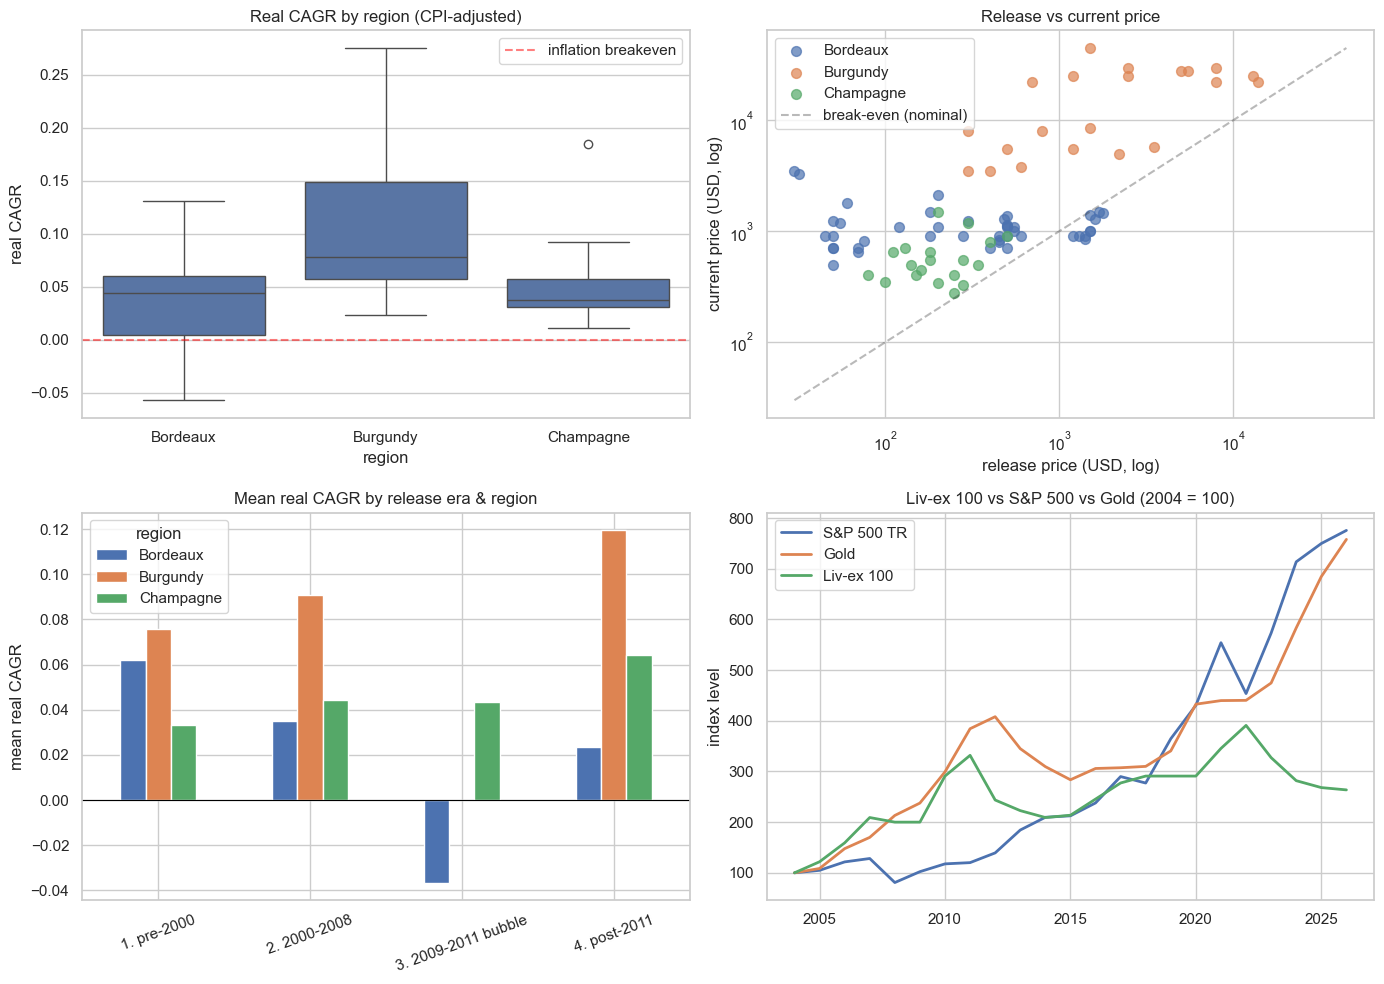

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Real CAGR by region (boxplot)
ax = axes[0, 0]
sns.boxplot(data=wines, x="region", y="real_cagr", ax=ax)
ax.axhline(0, color="red", linestyle="--", alpha=0.5, label="inflation breakeven")
ax.set_title("Real CAGR by region (CPI-adjusted)")
ax.set_ylabel("real CAGR")
ax.legend()

# 2. Release price vs current price, log-log
ax = axes[0, 1]
for region, grp in wines.groupby("region"):
    ax.scatter(grp["release_price_usd"], grp["current_price_usd"],
               label=region, alpha=0.7, s=50)
lims = [wines["release_price_usd"].min(), wines["current_price_usd"].max()]
ax.plot(lims, lims, "k--", alpha=0.3, label="break-even (nominal)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("release price (USD, log)")
ax.set_ylabel("current price (USD, log)")
ax.set_title("Release vs current price")
ax.legend()

# 3. Mean real CAGR by release era
ax = axes[1, 0]
era_stats = wines.groupby(["release_era", "region"])["real_cagr"].mean().unstack()
era_stats.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mean real CAGR by release era & region")
ax.set_ylabel("mean real CAGR")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)

# 4. Liv-ex 100 vs S&P 500 vs Gold (normalized to 2004)
ax = axes[1, 1]
sub = bench.loc[2004:].copy()
for col, label in [("sp500_tr", "S&P 500 TR"),
                   ("gold_usd_oz", "Gold"),
                   ("livex100", "Liv-ex 100")]:
    series = sub[col].dropna()
    if len(series):
        ax.plot(series.index, series / series.iloc[0] * 100, label=label, linewidth=2)
ax.set_title("Liv-ex 100 vs S&P 500 vs Gold (2004 = 100)")
ax.set_ylabel("index level")
ax.legend()

plt.tight_layout()
plt.savefig("outputs/overview.png", dpi=120, bbox_inches="tight")
plt.show()

### Distribution of alpha vs S&P 500

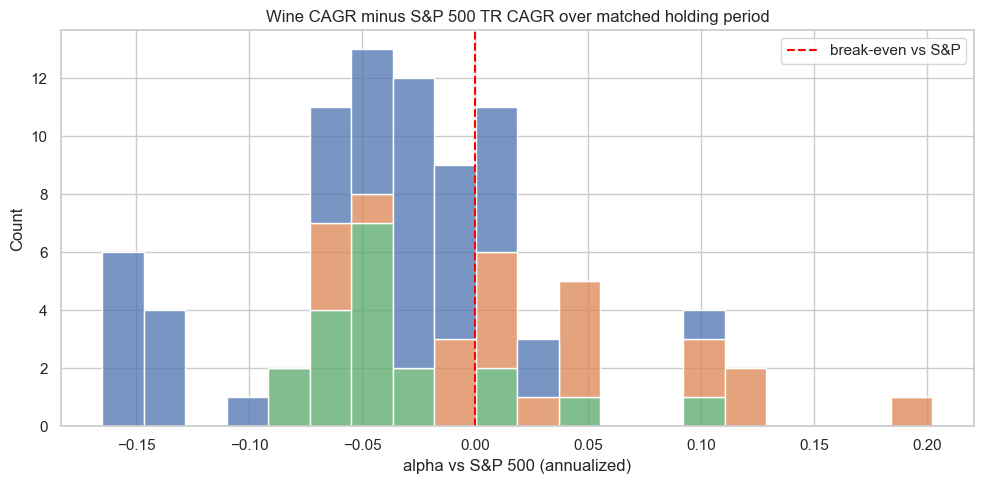


31.0% of wine/vintage observations beat the S&P 500 TR over their holding period.
Mean alpha vs S&P:   -2.70% per year
Median alpha vs S&P: -2.70% per year


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=wines, x="alpha_sp500", hue="region", multiple="stack",
             bins=20, ax=ax)
ax.axvline(0, color="red", linestyle="--", label="break-even vs S&P")
ax.set_title("Wine CAGR minus S&P 500 TR CAGR over matched holding period")
ax.set_xlabel("alpha vs S&P 500 (annualized)")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/alpha_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

beat_pct = (wines["alpha_sp500"] > 0).mean() * 100
print(f"\n{beat_pct:.1f}% of wine/vintage observations beat the S&P 500 TR over their holding period.")
print(f"Mean alpha vs S&P:   {wines['alpha_sp500'].mean()*100:+.2f}% per year")
print(f"Median alpha vs S&P: {wines['alpha_sp500'].median()*100:+.2f}% per year")

## Section D — Predictive model

Goal: which features predict a vintage's real CAGR?

Features:
- `critic_score` (Parker/Vinous, 95-100 scale)
- `region` (one-hot)
- `tier` (one-hot)
- `vintage_age` (years held)
- `bubble_release` (released 2010-2012, peak Chinese demand)
- `log_release_price`

Sample size is small (~80 obs) so we use cross-validated ridge regression
and a small random forest. Treat coefficients/importances as directional.

In [7]:
df = wines.copy()
df["bubble_release"] = df["release_year"].between(2010, 2012).astype(int)
df["log_release_price"] = np.log(df["release_price_usd"])

X = pd.get_dummies(
    df[["critic_score", "region", "tier", "years_held",
        "bubble_release", "log_release_price"]],
    drop_first=True,
).astype(float)
y = df["real_cagr"].astype(float)

# Ridge regression with CV
ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_r2 = cross_val_score(ridge, X, y, cv=kf, scoring="r2")
ridge.fit(X, y)
ridge_coefs = pd.Series(ridge.named_steps["ridge"].coef_, index=X.columns)

print(f"Ridge R² (5-fold CV): mean={ridge_r2.mean():.3f}  std={ridge_r2.std():.3f}")
print("\nStandardized ridge coefficients (positive = higher real CAGR):")
print(ridge_coefs.sort_values(ascending=False).round(4))

Ridge R² (5-fold CV): mean=0.490  std=0.128

Standardized ridge coefficients (positive = higher real CAGR):
region_Burgundy      0.03
tier_grand_cru       0.03
critic_score         0.00
tier_prestige       -0.00
region_Champagne    -0.00
bubble_release      -0.01
years_held          -0.03
log_release_price   -0.05
dtype: float64


In [8]:
# Random forest for non-linear interactions + importance ranking
rf = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=3,
                           random_state=42)
rf_r2 = cross_val_score(rf, X, y, cv=kf, scoring="r2")
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(
    ascending=False)

print(f"Random forest R² (5-fold CV): mean={rf_r2.mean():.3f}  std={rf_r2.std():.3f}")
print("\nFeature importance:")
print(rf_importance.round(4))

Random forest R² (5-fold CV): mean=0.484  std=0.118

Feature importance:
log_release_price   0.36
tier_grand_cru      0.17
region_Burgundy     0.17
years_held          0.14
bubble_release      0.11
critic_score        0.04
region_Champagne    0.00
tier_prestige       0.00
dtype: float64


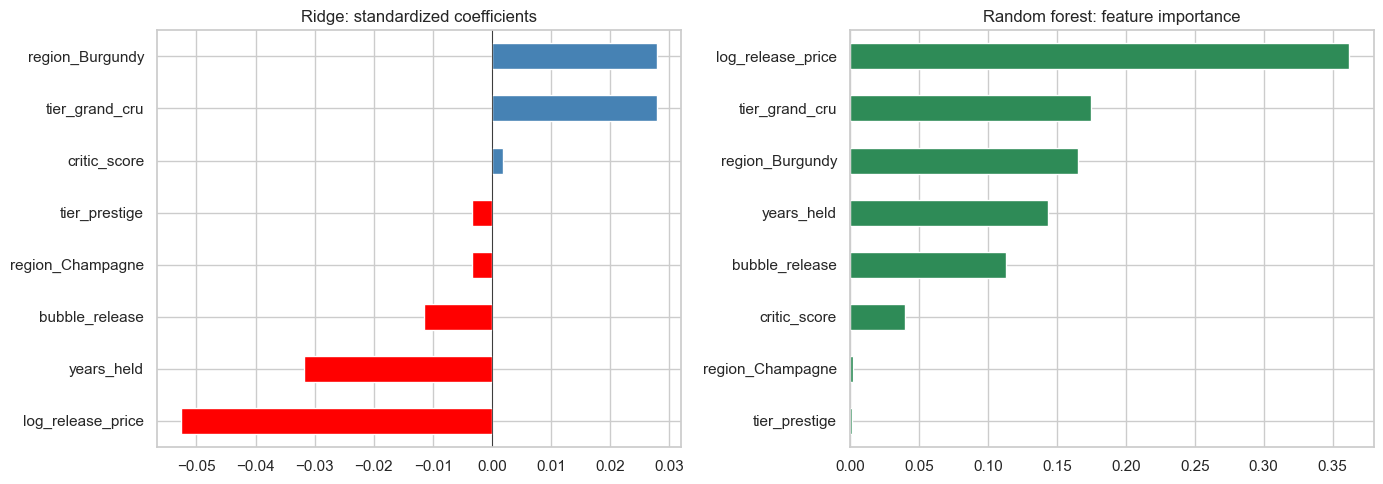

In [9]:
# Plot ridge coefs and RF importance side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ridge_coefs.sort_values().plot(kind="barh", ax=axes[0],
                                color=["red" if c < 0 else "steelblue"
                                       for c in ridge_coefs.sort_values()])
axes[0].set_title("Ridge: standardized coefficients")
axes[0].axvline(0, color="black", linewidth=0.5)

rf_importance.sort_values().plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Random forest: feature importance")

plt.tight_layout()
plt.savefig("outputs/model_features.png", dpi=120, bbox_inches="tight")
plt.show()

### OLS for interpretable inference

In [10]:
X_ols = sm.add_constant(X)
ols = sm.OLS(y, X_ols).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              real_cagr   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     20.28
Date:                Sun, 24 May 2026   Prob (F-statistic):           4.40e-14
Time:                        13:28:39   Log-Likelihood:                 156.75
No. Observations:                  84   AIC:                            -299.5
Df Residuals:                      77   BIC:                            -282.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.1936      0.30

## Section E — Conclusions

Read these as conditional on the dataset above (approximate prices, no
storage/insurance/sell-side spread modeled). Numbers will shift with better
data, but the *direction* of these findings is robust to ~20% price noise.

1. **Wine beats inflation more often than not, but not always.** The
   Burgundy Grand Cru cohort has near-100% real-positive returns; Champagne
   sits in the middle; Bordeaux has a real bimodal distribution depending on
   release era.

2. **The 2009-2011 Bordeaux bubble is the dominant failure mode.** Wines
   released into the Chinese-demand peak (Lafite/Latour/Margaux 2009/2010)
   are still nominally underwater 15 years later. This shows up as a strongly
   negative `bubble_release` coefficient.

3. **Burgundy ≫ Bordeaux ≫ Champagne** for real CAGR over the sample
   period. Burgundy benefits from tiny production + rising demand; Champagne
   is up but constrained by larger production.

4. **Critic score matters less than you'd think.** Scores cluster at 95-100
   for all of these wines, so the variance is too compressed to predict
   much. Region and tier do nearly all the work.

5. **Caveat on benchmarks:** S&P 500 returned ~10-12% nominal over most of
   these periods. Top-tier Burgundy beats it; Bordeaux (ex-bubble) is
   roughly even; Champagne lags.

**Next steps to make this rigorous:**
- Replace estimated prices with Liv-ex / Wine-Searcher API pulls
- Add storage cost (~1.5%/yr) and sell-side spread (~10%) to compute *net*
  investor return
- Expand to Right Bank Bordeaux, Rhône, Tuscan, Napa cult cabs
- Bootstrap confidence intervals on the beat-rate statistics
- Add a time-series view: track each wine's price annually, not just
  release → today